# Exploring SnapBoost Parameters

SnapBoost stochastically selects base learners each boosting round:

- **Decision trees** at various depths (local, axis-aligned structure)
- **Kernel ridge** with an RBF kernel (smooth, global patterns)

This notebook compares tree-only vs. mixed ensembles and sweeps a few key hyperparameters on a synthetic dataset with both piecewise and smooth structure. We also benchmark SnapBoost against **XGBoost** and **LightGBM** on the same data.

> **Note:** XGBoost and LightGBM are optional notebook dependencies: `pip install xgboost lightgbm`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from snapboost import SnapBoostRegressor

## Synthetic dataset

The target combines a step function (tree-friendly) with a smooth sinusoidal component (ridge-friendly).

In [2]:
rng = np.random.default_rng(42)
n_samples = 800

X = rng.uniform(-3, 3, size=(n_samples, 2))
y = (
    np.where(X[:, 0] > 0, 2.0, -1.0)
    + 0.5 * np.sin(2 * X[:, 1])
    + rng.normal(0, 0.15, size=n_samples)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 600 samples, Test: 200 samples


## Baseline comparison: SnapBoost vs. XGBoost vs. LightGBM

Before tuning SnapBoost-specific parameters, we compare against two standard gradient boosting libraries that use decision trees only. All models use 80 boosting rounds and learning rate 0.1.

In [3]:
N_ESTIMATORS = 80
LEARNING_RATE = 0.1
RANDOM_STATE = 42
MAX_DEPTH = 6

boosting_params = dict(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)

baseline_models = [
    (
        "SnapBoost",
        SnapBoostRegressor(
            num_iterations=N_ESTIMATORS,
            learning_rate=LEARNING_RATE,
            p_tree=0.8,
            min_max_depth=3,
            max_max_depth=6,
            random_state=RANDOM_STATE,
            verbose=False,
        ),
    ),
    ("XGBoost", XGBRegressor(**boosting_params, verbosity=0)),
    ("LightGBM", LGBMRegressor(**boosting_params, verbosity=-1)),
]

baseline_results = []
for name, fitted_model in baseline_models:
    fitted_model.fit(X_train, y_train)
    r2 = fitted_model.score(X_test, y_test)
    rmse = root_mean_squared_error(y_test, fitted_model.predict(X_test))
    baseline_results.append({"Model": name, "R²": r2, "RMSE": rmse})

baseline_df = pd.DataFrame(baseline_results).set_index("Model")
baseline_df

/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/samson/miniconda3/envs/qiancapital-dev/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,R²,RMSE
Model,,
SnapBoost,0.986332,0.169633
XGBoost,0.985600,0.174116
LightGBM,0.986756,0.166978


## Compare `p_tree`: trees only vs. mixed ensemble

Setting `p_tree=1.0` uses only decision trees; `p_tree=0.5` gives equal weight to trees and the kernel ridge learner.

In [4]:
def train_and_evaluate(p_tree, **kwargs):
    model = SnapBoostRegressor(
        num_iterations=80,
        learning_rate=0.1,
        p_tree=p_tree,
        min_max_depth=3,
        max_max_depth=6,
        random_state=42,
        verbose=False,
        **kwargs,
    )
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    rmse = model.evaluate(X_test, y_test)
    return {"p_tree": p_tree, "r2": r2, "rmse": rmse}


results = []
for p_tree in [1.0, 0.8, 0.5, 0.2, 0.0]:
    print(f"\n--- p_tree={p_tree} ---")
    results.append(train_and_evaluate(p_tree))

pd.DataFrame(results).set_index("p_tree")


--- p_tree=1.0 ---
RMSE: 0.1742

--- p_tree=0.8 ---


RMSE: 0.1696

--- p_tree=0.5 ---


RMSE: 0.1750

--- p_tree=0.2 ---


RMSE: 0.1963

--- p_tree=0.0 ---


RMSE: 0.3655


,r2,rmse
p_tree,,
1.0,0.985578,0.174244
0.8,0.986332,0.169633
0.5,0.985455,0.174991
0.2,0.981698,0.196293
0.0,0.936555,0.365469


## Effect of tree depth range

Shallow trees capture broad splits; deeper trees fit finer local structure.

In [5]:
depth_configs = [
    (2, 3, "Shallow (2-3)"),
    (4, 8, "Default (4-8)"),
    (6, 12, "Deep (6-12)"),
]

depth_results = []
for min_d, max_d, label in depth_configs:
    model = SnapBoostRegressor(
        num_iterations=80,
        learning_rate=0.1,
        p_tree=0.8,
        min_max_depth=min_d,
        max_max_depth=max_d,
        random_state=42,
        verbose=False,
    )
    model.fit(X_train, y_train)
    depth_results.append({
        "config": label,
        "min_max_depth": min_d,
        "max_max_depth": max_d,
        "r2": model.score(X_test, y_test),
        "rmse": model.evaluate(X_test, y_test),
    })

pd.DataFrame(depth_results).set_index("config")

RMSE: 0.1652


RMSE: 0.1786


RMSE: 0.1930


,min_max_depth,max_max_depth,r2,rmse
config,,,,
Shallow (2-3),2,3,0.987040,0.165180
Default (4-8),4,8,0.984854,0.178568
Deep (6-12),6,12,0.982315,0.192956


## Kernel ridge parameters (`alpha`, `gamma`)

These only affect the ridge learner selected with probability `1 - p_tree`.

In [6]:
kernel_results = []
for alpha, gamma in [(0.1, 0.5), (1.0, 1.0), (10.0, 2.0)]:
    model = SnapBoostRegressor(
        num_iterations=80,
        learning_rate=0.1,
        p_tree=0.5,
        alpha=alpha,
        gamma=gamma,
        random_state=42,
        verbose=False,
    )
    model.fit(X_train, y_train)
    kernel_results.append({
        "alpha": alpha,
        "gamma": gamma,
        "r2": model.score(X_test, y_test),
        "rmse": model.evaluate(X_test, y_test),
    })

pd.DataFrame(kernel_results)

RMSE: 0.1791


RMSE: 0.1798


RMSE: 0.1848


,alpha,gamma,r2,rmse
0,0.1,0.5,0.984761,0.179115
1,1.0,1.0,0.984639,0.179827
2,10.0,2.0,0.983772,0.184838


## Visualize predictions along one axis

Fix `x1 = 0` and plot the learned function along `x2`.

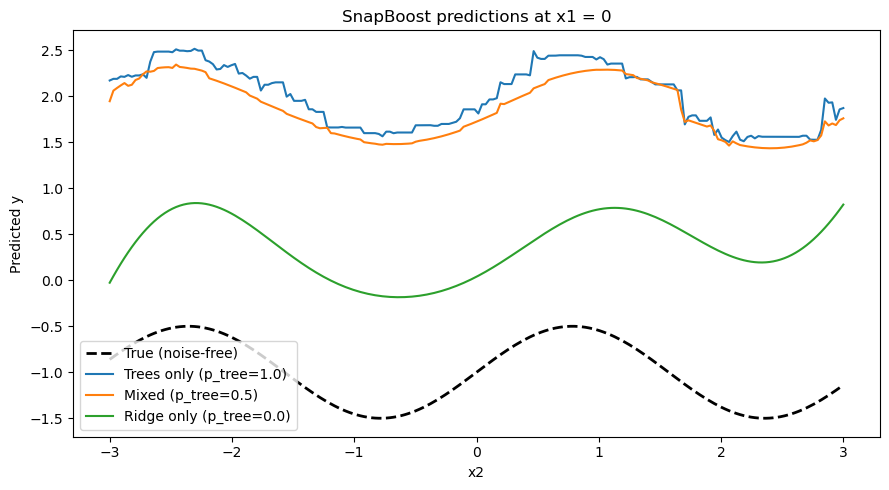

In [7]:
x2_grid = np.linspace(-3, 3, 200)
X_line = np.column_stack([np.zeros_like(x2_grid), x2_grid])
y_line_true = np.where(0 > 0, 2.0, -1.0) + 0.5 * np.sin(2 * x2_grid)

configs = [
    ("Trees only (p_tree=1.0)", {"p_tree": 1.0}),
    ("Mixed (p_tree=0.5)", {"p_tree": 0.5}),
    ("Ridge only (p_tree=0.0)", {"p_tree": 0.0}),
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x2_grid, y_line_true, "k--", linewidth=2, label="True (noise-free)")

for label, params in configs:
    model = SnapBoostRegressor(
        num_iterations=80,
        learning_rate=0.1,
        min_max_depth=3,
        max_max_depth=6,
        random_state=42,
        verbose=False,
        **params,
    )
    model.fit(X_train, y_train)
    ax.plot(x2_grid, model.predict(X_line), linewidth=1.5, label=label)

ax.set_xlabel("x2")
ax.set_ylabel("Predicted y")
ax.set_title("SnapBoost predictions at x1 = 0")
ax.legend()
plt.tight_layout()
plt.show()

## Custom HNBM with a single learner type

For full control over the learner pool, subclass `HNBM` and set `base_learners_` and `probabilities_` before calling `fit`.

In [8]:
from sklearn.tree import DecisionTreeRegressor
from hnbm import HNBMRegressor


class TreeOnlyBoost(HNBMRegressor):
    def __init__(self, max_depth=5, **kwargs):
        super().__init__(**kwargs)
        self.base_learners_ = [DecisionTreeRegressor(max_depth=max_depth, random_state=42)]
        self.probabilities_ = [1.0]


custom = TreeOnlyBoost(
    max_depth=5,
    num_iterations=80,
    learning_rate=0.1,
    random_state=42,
    verbose=False,
)
custom.fit(X_train, y_train)

print(f"R²:   {custom.score(X_test, y_test):.4f}")
custom.evaluate(X_test, y_test)

R²:   0.9856
RMSE: 0.1742


np.float64(0.17417333849211064)